Dự đoán khả năng trả nợ của khách hàng

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl as op

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, accuracy_score

from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

Data Cleaning

In [ ]:
df = pd.read_csv("Data/accepted_2007_to_2018Q4.csv")

print(df.head())
print(df.info())

         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...                            NaN   

  hardship_last_payment_amount disbursement_

In [3]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,dti,fico_range_low,fico_range_high,inq_last_6mths,...,sec_app_collections_12_mths_ex_med,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,1.048563e+06,1.048563e+06,1.048563e+06,1.048563e+06,1.048563e+06,1.047707e+06,1.048563e+06,1.048563e+06,1.048560e+06,...,54916.000000,6112.0,6112.000000,6112.0,6112.000000,4882.000000,6112.000000,18709.000000,18709.000000,18709.000000
mean,NaN,1.525010e+04,1.525008e+04,1.524465e+04,1.277206e+01,4.477775e+02,1.932870e+01,6.981973e+02,7.021947e+02,5.239586e-01,...,0.074969,3.0,149.944000,3.0,13.751145,442.292636,11373.446041,5046.343797,47.800842,13.782939
std,NaN,9.227339e+03,9.227341e+03,9.225066e+03,4.853020e+00,2.669758e+02,1.483840e+01,3.306644e+01,3.309554e+01,8.218733e-01,...,0.394082,0.0,128.619238,0.0,9.670893,377.751498,7594.447952,3697.810115,6.477393,7.704838
min,NaN,1.000000e+03,1.000000e+03,7.500000e+02,5.310000e+00,1.401000e+01,-1.000000e+00,6.600000e+02,0.000000e+00,0.000000e+00,...,0.000000,3.0,0.640000,3.0,0.000000,1.920000,55.730000,107.000000,0.450000,0.000000
25%,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.170000e+00,2.541700e+02,1.220000e+01,6.700000e+02,6.740000e+02,0.000000e+00,...,0.000000,3.0,54.737500,3.0,5.000000,162.067500,5406.835000,2211.000000,45.000000,8.000000
50%,NaN,1.320000e+04,1.320000e+04,1.320000e+04,1.229000e+01,3.797600e+02,1.827000e+01,6.900000e+02,6.940000e+02,0.000000e+00,...,0.000000,3.0,114.150000,3.0,15.000000,340.950000,9700.290000,4216.000000,45.000000,14.000000
75%,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.559000e+01,5.955250e+02,2.515000e+01,7.150000e+02,7.190000e+02,1.000000e+00,...,0.000000,3.0,207.630000,3.0,22.000000,606.727500,15820.962500,6910.160000,50.000000,18.000000
max,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,9.990000e+02,8.450000e+02,8.500000e+02,1.700000e+01,...,18.000000,3.0,943.940000,3.0,32.000000,2680.890000,40306.410000,30000.000000,166.670000,118.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Columns: 151 entries, id to settlement_term
dtypes: float64(105), object(9), str(37)
memory usage: 1.4+ GB


In [6]:
df.shape

(1048575, 151)

In [7]:
#check null
print(df.isnull().sum())

print(df.columns)


id                             0
member_id                1048575
loan_amnt                     12
funded_amnt                   12
funded_amnt_inv               12
                          ...   
settlement_status        1029866
settlement_date          1029866
settlement_amount        1029866
settlement_percentage    1029866
settlement_term          1029866
Length: 151, dtype: int64
Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='str', length=151)


In [8]:
df.isnull().sum().sort_values(ascending=False).head(10)

member_id                                     1048575
desc                                          1048514
orig_projected_additional_accrued_interest    1043693
hardship_payoff_balance_amount                1042463
hardship_loan_status                          1042463
hardship_length                               1042463
hardship_type                                 1042463
payment_plan_start_date                       1042463
hardship_start_date                           1042463
hardship_status                               1042463
dtype: int64

##Drop columns with > 70% missing value

In [9]:
#drop những cột missing cao
missing = df.isnull().mean()
drop_cols = missing[missing > 0.7].index.tolist()
df.drop(columns=drop_cols, inplace=True)

##Drop Irrelevant Columns (ID, URLs, Descriptions, etc.)

In [10]:
irrelevant_cols = [
    'id', 'member_id', 'url', 'desc', 'title', 'zip_code', 'application_type',
    'policy_code', 'emp_title', 'pymnt_plan'
]
df.drop(columns=[col for col in irrelevant_cols if col in df.columns], inplace=True)


In [11]:
df.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
       ...
       'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
       'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit', 'hardship_flag', 'disbursement_method',
       'debt_settlement_flag'],
      dtype='str', length=102)

##Filter to Only Loans with Outcome

In [12]:
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])]

df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,...,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,...,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,...,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N
4,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,...,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N
5,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,...,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,N,Cash,N


In [13]:
df['loan_status'].value_counts(dropna=False)

loan_status
Fully Paid     482594
Charged Off    129186
Name: count, dtype: int64

##Create Binary Target Variable

In [14]:
df['loan_default'] = df['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)
df.drop(columns=['loan_status'], inplace=True)

##Convert Date Columns

In [15]:
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
date_cols = ['last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='%b-%Y', errors='coerce')

##Impute Remaining Missing Values (Median or Category)

In [16]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [17]:
df.isnull().sum().sort_values(ascending=False).head(10)

last_pymnt_d          611780
issue_d               611780
last_credit_pull_d    611780
next_pymnt_d          611780
funded_amnt_inv            0
term                       0
installment                0
int_rate                   0
emp_length                 0
grade                      0
dtype: int64

In [18]:
cols_to_drop = [
    'last_pymnt_d',
    'issue_d',
    'last_credit_pull_d',
    'next_pymnt_d'
]

df = df.drop(columns=cols_to_drop).copy()


##Check null row

In [19]:
print(df.isnull().sum())

print(df.columns)

loan_amnt                     0
funded_amnt                   0
funded_amnt_inv               0
term                          0
int_rate                      0
                             ..
total_il_high_credit_limit    0
hardship_flag                 0
disbursement_method           0
debt_settlement_flag          0
loan_default                  0
Length: 98, dtype: int64
Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'purpose', 'addr_state', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
       'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'initial_list_status',
       'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recov

##Check Duplicates

In [20]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [21]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,loan_default
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,...,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,...,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,...,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0
4,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,...,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N,0
5,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,...,0.0,0.0,16900.0,12798.0,9400.0,4000.0,N,Cash,N,0


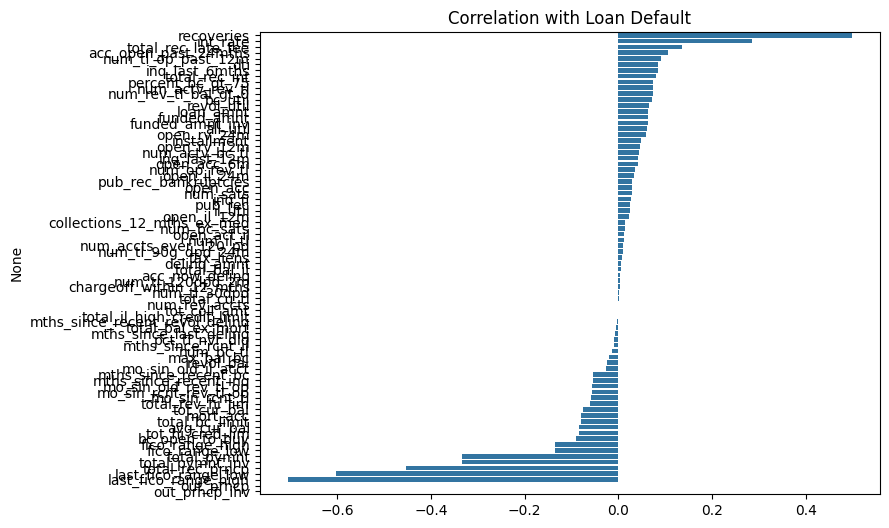

In [22]:
corr_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = corr_df.corr()

target_corr = correlation_matrix['loan_default'].sort_values(ascending=False)

# bỏ chính nó (self-correlation)
target_corr = target_corr.drop('loan_default')

plt.figure(figsize=(8,6))
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title("Correlation with Loan Default")
plt.show()


In [23]:
print(target_corr.head(10))


recoveries              0.498293
int_rate                0.285595
total_rec_late_fee      0.136086
acc_open_past_24mths    0.106564
num_tl_op_past_12m      0.090402
dti                     0.085265
inq_last_6mths          0.083920
total_rec_int           0.081233
percent_bc_gt_75        0.074349
num_actv_rev_tl         0.074283
Name: loan_default, dtype: float64


In [24]:
leakage_cols = [
    'recoveries',
    'collection_recovery_fee',
    'total_rec_late_fee',
    'total_rec_int'
]

df = df.drop(columns=leakage_cols)


##Create Clean dataset

In [25]:
#df.to_csv("cleaned_lendingclub.csv", index=False)

In [26]:
df = pd.read_csv("cleaned_lendingclub.csv")

print(df.head())
print(df.info())

FileNotFoundError: [Errno 2] No such file or directory: 'cleaned_lendingclub.csv'

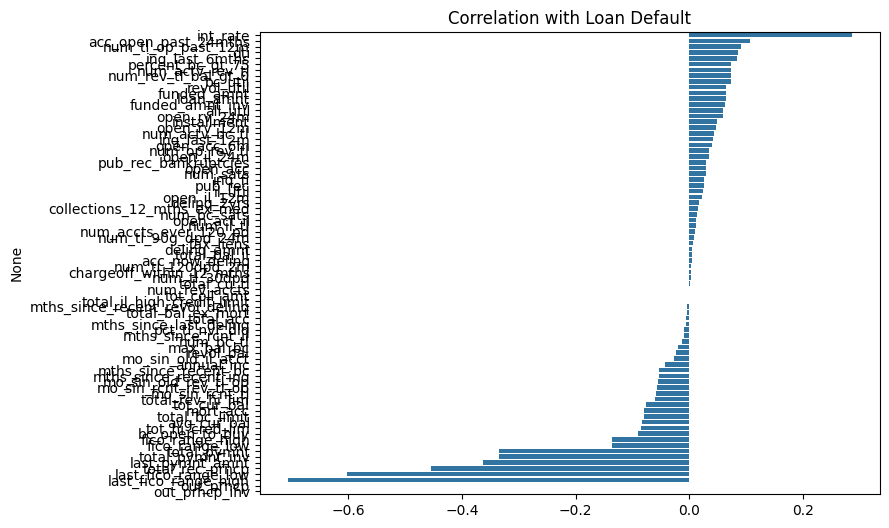

In [ ]:
corr_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = corr_df.corr()

target_corr = correlation_matrix['loan_default'].sort_values(ascending=False)

# bỏ chính nó (self-correlation)
target_corr = target_corr.drop('loan_default')

plt.figure(figsize=(8,6))
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title("Correlation with Loan Default")
plt.show()

In [ ]:
print(target_corr.head(10))

int_rate                0.285595
acc_open_past_24mths    0.106564
num_tl_op_past_12m      0.090402
dti                     0.085265
inq_last_6mths          0.083920
percent_bc_gt_75        0.074349
num_actv_rev_tl         0.074283
num_rev_tl_bal_gt_0     0.073434
bc_util                 0.072857
revol_util              0.064630
Name: loan_default, dtype: float64
